In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import normaltest
import re

Calculating z-scores for the Brunello library screened with tracr v2 (Sanson, *Nature Communications*, 2018) for comparison to screening of the Jacquere library

In [2]:
reads_df= pd.read_excel("../Data/Brunello_Sanson2018_SuppData1.xlsx",sheet_name="A375_mod_tracr raw reads",skiprows=1)
reads_df

,sgRNA Sequence,pDNA,RepA,RepB,RepC
0,AAAAAAAATCCGGACAATGG,247,358,1146,623
1,AAAAAAAGGATGGTGATCAA,119,1313,431,1078
2,AAAAAAATGACATTACTGCA,139,117,163,82
3,AAAAAAATGTCAGTCGAGTG,76,970,984,681
4,AAAAAACACAAGCAAGACCG,62,681,435,961
...,...,...,...,...,...
77436,TTTGTTTGGATTGCTTCAAG,226,207,94,165
77437,TTTTACCTTGTTCACATGGA,262,2406,2728,2472
77438,TTTTGACTCTAATCACCGGT,151,2654,2586,3860
77439,TTTTTAATACAAGGTAATCT,105,690,424,213


In [3]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads
condition_columns = ['pDNA', 'RepA', 'RepB',
                     'RepC']
lognorm_df = reads_df.copy()
lognorm_df[condition_columns] = lognorm_df[condition_columns].apply(lognorm)
condition_columns.remove("pDNA")
lognorm_df

,sgRNA Sequence,pDNA,RepA,RepB,RepC
0,AAAAAAAATCCGGACAATGG,4.890963,2.736833,4.131168,3.454210
1,AAAAAAAGGATGGTGATCAA,3.888789,4.444986,2.850820,4.188607
2,AAAAAAATGACATTACTGCA,4.098830,1.511850,1.744210,1.208506
3,AAAAAAATGTCAGTCGAGTG,3.295977,4.031409,3.924783,3.571378
4,AAAAAACACAAGCAAGACCG,3.035039,3.558043,2.862307,4.032459
...,...,...,...,...,...
77436,TTTGTTTGGATTGCTTCAAG,4.767286,2.096324,1.235899,1.863126
77437,TTTTACCTTGTTCACATGGA,4.973232,5.288347,5.333851,5.340608
77438,TTTTGACTCTAATCACCGGT,4.211587,5.426425,5.258693,5.970671
77439,TTTTTAATACAAGGTAATCT,3.721145,3.575386,2.830494,2.139258


In [4]:
#remove underrepresented sgRNAs
filtered_lognorms = lognorm_df.copy()
z_low = -3  # minimum z-score
# Z-score the pDNA column
filtered_lognorms["pDNA_zscore"] = (filtered_lognorms['pDNA'] - filtered_lognorms['pDNA'].mean())/filtered_lognorms['pDNA'].std()
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms["pDNA_zscore"] > z_low].reset_index(drop=True)
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop("pDNA_zscore", axis=1)
filtered_lognorms

,sgRNA Sequence,pDNA,RepA,RepB,RepC
0,AAAAAAAATCCGGACAATGG,4.890963,2.736833,4.131168,3.454210
1,AAAAAAAGGATGGTGATCAA,3.888789,4.444986,2.850820,4.188607
2,AAAAAAATGACATTACTGCA,4.098830,1.511850,1.744210,1.208506
3,AAAAAAATGTCAGTCGAGTG,3.295977,4.031409,3.924783,3.571378
4,AAAAAACACAAGCAAGACCG,3.035039,3.558043,2.862307,4.032459
...,...,...,...,...,...
77102,TTTGTTTGGATTGCTTCAAG,4.767286,2.096324,1.235899,1.863126
77103,TTTTACCTTGTTCACATGGA,4.973232,5.288347,5.333851,5.340608
77104,TTTTGACTCTAATCACCGGT,4.211587,5.426425,5.258693,5.970671
77105,TTTTTAATACAAGGTAATCT,3.721145,3.575386,2.830494,2.139258


In [5]:
lfc_df = filtered_lognorms.copy()
for col in condition_columns:
    lfc_df[col] = filtered_lognorms[col] - filtered_lognorms["pDNA"]
lfc_df=lfc_df.drop("pDNA",axis=1)
lfc_df

,sgRNA Sequence,RepA,RepB,RepC
0,AAAAAAAATCCGGACAATGG,-2.154130,-0.759795,-1.436753
1,AAAAAAAGGATGGTGATCAA,0.556197,-1.037969,0.299818
2,AAAAAAATGACATTACTGCA,-2.586980,-2.354621,-2.890325
3,AAAAAAATGTCAGTCGAGTG,0.735432,0.628806,0.275401
4,AAAAAACACAAGCAAGACCG,0.523004,-0.172731,0.997420
...,...,...,...,...
77102,TTTGTTTGGATTGCTTCAAG,-2.670962,-3.531387,-2.904160
77103,TTTTACCTTGTTCACATGGA,0.315115,0.360619,0.367376
77104,TTTTGACTCTAATCACCGGT,1.214838,1.047106,1.759083
77105,TTTTTAATACAAGGTAATCT,-0.145759,-0.890650,-1.581887


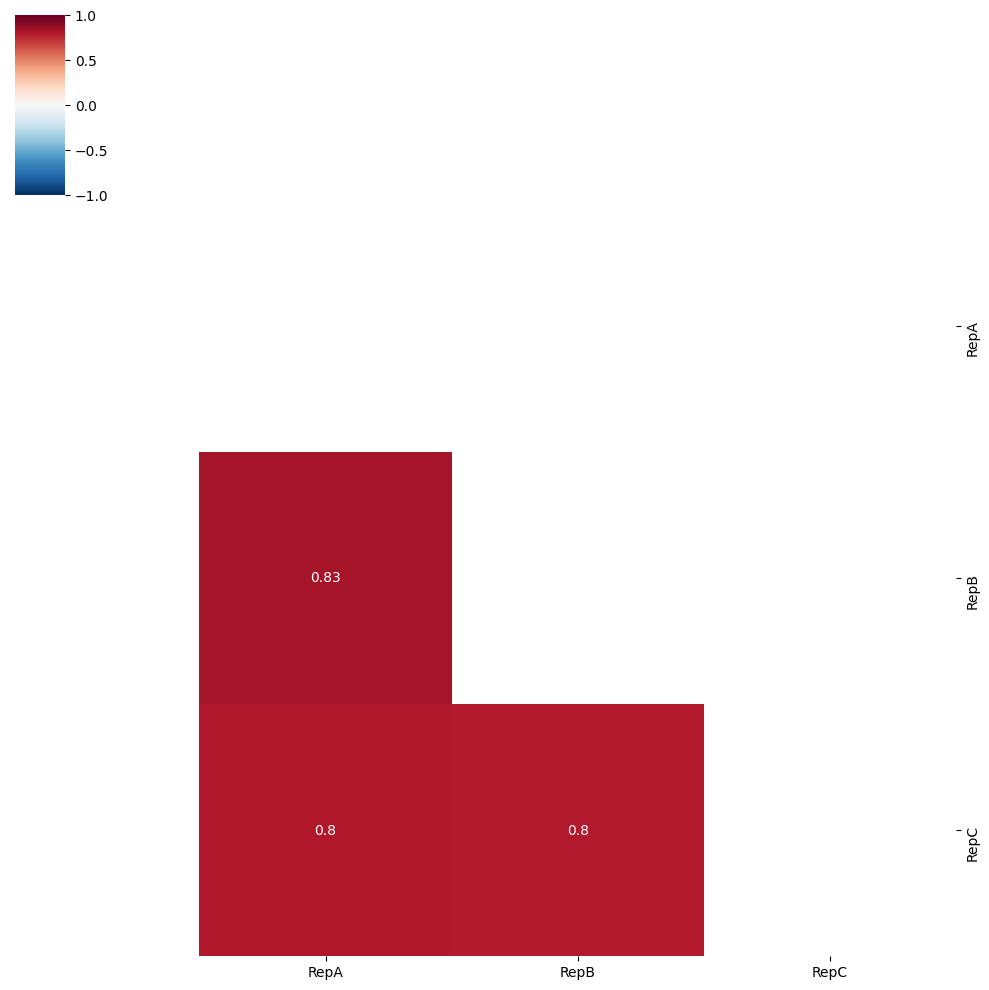

In [6]:
#check replicate correlation
lfc_correlations = lfc_df.corr(numeric_only=True)
matrix=np.triu(lfc_correlations)
sns.clustermap(lfc_correlations, cmap='RdBu_r',
               vmin=-1, vmax=1, annot=True,row_cluster=False,col_cluster=False,mask=matrix)

In [7]:
#adequate replicate correlation: take average
lfc_df["sgRNA_lfc"]=lfc_df.mean(axis=1,numeric_only=True)
lfc_df=lfc_df.drop(condition_columns,axis=1)
lfc_df

,sgRNA Sequence,sgRNA_lfc
0,AAAAAAAATCCGGACAATGG,-1.450226
1,AAAAAAAGGATGGTGATCAA,-0.060651
2,AAAAAAATGACATTACTGCA,-2.610642
3,AAAAAAATGTCAGTCGAGTG,0.546546
4,AAAAAACACAAGCAAGACCG,0.449231
...,...,...
77102,TTTGTTTGGATTGCTTCAAG,-3.035503
77103,TTTTACCTTGTTCACATGGA,0.347703
77104,TTTTGACTCTAATCACCGGT,1.340342
77105,TTTTTAATACAAGGTAATCT,-0.872765


In [8]:
#get guide mappings, info from CRISPick 
brunello_crispick_info=pd.read_table("../../5. Assessment of  CRISPRko Cas9 Genome Wide Libraries/Data/CRISPick evaluated CRISPRko Cas9 Genome Wide Libraries/brunello_2_10_2025-sgrna-designs.txt")
brunello_crispick_info=brunello_crispick_info[brunello_crispick_info["Picking Notes"].str.count("Preselect")>0]
#remove targeting guides that no longer map in Ensembl v113
brunello_crispick_info=brunello_crispick_info[brunello_crispick_info["Other Target Matches"]!= "POTENTIALLY_ACTIVE"]
intergenic_controls=brunello_crispick_info[brunello_crispick_info["Other Target Matches"]=="ONE_INTERGENIC_SITE"]["sgRNA Sequence"].tolist()
#add additional genes to which guides map as unique rows
brunello_crispick_info["Other Target Matches"]=brunello_crispick_info["Other Target Matches"].apply(lambda x: re.split(', |( |) ', x) if type(x)!=float else "")
brunello_crispick_info["Other Target Matches"]=brunello_crispick_info["Other Target Matches"].apply(lambda x: [other_target.replace("(","").replace(")","") for other_target in x if other_target!=None and len(other_target)>0])
brunello_crispick_info["Other Target Matches"]=brunello_crispick_info["Other Target Matches"].apply(lambda x: [gene for gene in x if gene.count("ENSG")==0 and gene.count("LINC")==0])
additional_guide_targets=brunello_crispick_info[brunello_crispick_info["Other Target Matches"].str.len()>0][["sgRNA Sequence","Other Target Matches"]].explode("Other Target Matches")
additional_guide_targets=additional_guide_targets.rename(columns={"Other Target Matches":"Target Gene Symbol"})
brunello_all_mappings= pd.concat([brunello_crispick_info,additional_guide_targets])
brunello_all_mappings=brunello_all_mappings.drop_duplicates(subset=["sgRNA Sequence","Target Gene Symbol"],keep="first")
brunello_all_mappings=brunello_all_mappings[brunello_all_mappings["Target Gene Symbol"].isna()==False]
annotated_sgrna_lfcs=pd.merge(lfc_df,brunello_all_mappings,on="sgRNA Sequence")


/var/folders/nm/6_wl7tx50tq5bqfp8vzf4m6r0000gq/T/ipykernel_57281/440476064.py:2: DtypeWarning: Columns (26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  brunello_crispick_info=pd.read_table("../../5. Assessment of  CRISPRko Cas9 Genome Wide Libraries/Data/CRISPick evaluated CRISPRko Cas9 Genome Wide Libraries/brunello_2_10_2025-sgrna-designs.txt")


In [13]:
#export for comparison of hit-calling methods
annotated_sgrna_lfcs.to_csv("../Data/brunelloA375lfc.csv")

In [9]:
control_sgrna_lfcs = annotated_sgrna_lfcs[annotated_sgrna_lfcs["sgRNA Sequence"].isin(intergenic_controls)]
stat, p = normaltest(control_sgrna_lfcs["sgRNA_lfc"])
print('Statistics=%.3f, p=%.3f' % (stat, p),"length=",len(control_sgrna_lfcs))

control_sgrna_mean=control_sgrna_lfcs["sgRNA_lfc"].mean(axis=0)
control_sgrna_sd=control_sgrna_lfcs["sgRNA_lfc"].std(axis=0,numeric_only=True)
zscored_sgrna_lfcs=annotated_sgrna_lfcs.copy()
zscored_sgrna_lfcs['z_scored_sgRNA_lfc'] = (zscored_sgrna_lfcs['sgRNA_lfc'] - control_sgrna_mean)/control_sgrna_sd
zscored_sgrna_lfcs=zscored_sgrna_lfcs[['sgRNA Sequence', 'Target Gene ID',
       'Target Gene Symbol', 'Aggregate CFD Score', 'Off-Target CFD100 Hits',
       'Off-Target Tier I CFD100 Hits', 'On-Target Efficacy Score', 'z_scored_sgRNA_lfc']]



Statistics=4.492, p=0.106 length= 23


In [10]:
zscored_sgrna_lfcs.to_csv("../Data/brunello_zscores.csv",index=False)